In [1]:
import pandas as pd
import numpy.ma as ma
import numpy as np
from pandas import DataFrame
import matplotlib.pyplot as plt
import scipy as sc
import scipy.stats as sc
from scipy.stats import ttest_ind
import statsmodels
import statsmodels.stats.multitest as multi
import csv
import pathlib
from pathlib import Path

In [2]:
# Import data
data= pd.read_csv(r"path_to_input_folder\B1WT2uM_combine_topTable_ValidCellCount_POC.csv")

In [3]:
# Select relevant columns
data = data.loc[:, data.columns.intersection(['B1score','WTscore', 'chemicalName', 'finalWellAnno', 'annotatedTarget'])]

In [4]:
# Calculate differential effect of each compound on KRASG12V clone (B1) and WT cell line.
data['KRAS-G12V fold selectivity'] = data['WTscore'] / data['B1score']
data['KRAS-WT fold selectivity'] = data['B1score']/data['WTscore']

In [5]:
# reorder alphabetically by compound name
allexport = data.sort_values(by=['chemicalName'], ascending= True)

In [6]:
# 1. Count rows where 'well annotation' contains 'sample'
sample_rows = data[data['finalWellAnno'] == 'sample'].shape[0]

# 2. Count rows where 'well annotation' contains 'sample' and 'annotated target' contains 'RTK'
sample_rtk_rows = data[(data['finalWellAnno'] == 'sample') & 
                     (data['annotatedTarget'].str.contains('RTK', case=False, na=False))].shape[0]

# Print the results
print(f"Total number of rows where 'well annotation' is 'sample': {sample_rows}")
print(f"Total number of rows where 'well annotation' is 'sample' and 'annotated target' contains 'RTK': {sample_rtk_rows}")


Total number of rows where 'well annotation' is 'sample': 2383
Total number of rows where 'well annotation' is 'sample' and 'annotated target' contains 'RTK': 94


In [7]:
# Rename columns of dataframe to be exported
allexport.columns= ['Viability % of control HUVEC/TERT2-KRAS$^{G12V}$', 'well annotation', 'compound name', 'annotated target', 'Viability % of control HUVEC/TERT2-KRAS$^{WT}$', 'KRAS-G12V fold selectivity', 'KRAS-WT fold selectivity']

In [8]:
# reorder dataframe
allexport = allexport[['compound name', "well annotation", "annotated target", 
         "Viability % of control HUVEC/TERT2-KRAS$^{WT}$", 
         "Viability % of control HUVEC/TERT2-KRAS$^{G12V}$", 
         "KRAS-G12V fold selectivity", "KRAS-WT fold selectivity"]]

In [9]:
# set compound name as index
allexport = allexport.set_index('compound name')

In [10]:
# Export all data of screen including differential effect of commpounds
allexport.to_csv(r"path_to_output_folder\2uM_all_compounds.csv", index= True)

In [11]:
# Create DMSO dataframe for later graph plot.
searchfor = 'dmso'
dmso = allexport[allexport['well annotation'] == searchfor] 

In [12]:
# SENSITIVE filtering drugs which make cells sensitive - values that have larger MF1 values for WT than for mutants (which work best for Mutant) and for which p value < 0.05
sensitivity = allexport.where(allexport['KRAS-G12V fold selectivity']> 1.25)
sensitivity1 = sensitivity[sensitivity['KRAS-G12V fold selectivity'].notna()]
sensitivity2 = sensitivity1.sort_values(by=['KRAS-G12V fold selectivity'], ascending= True)
sensitivity3 = sensitivity2[(sensitivity2['Viability % of control HUVEC/TERT2-KRAS$^{G12V}$'] < 75) & (sensitivity2['Viability % of control HUVEC/TERT2-KRAS$^{WT}$'] > 25)]
sensitivity4 = sensitivity3[sensitivity3['KRAS-G12V fold selectivity'].notna()]

In [13]:
# Drop the column 'KRAS-WT fold selectivity'
sensitivityexport = sensitivity4.drop(columns=['KRAS-WT fold selectivity'])

In [14]:
# Rank by selectivity
sensitivityexport = sensitivityexport.sort_values(by=['KRAS-G12V fold selectivity'], ascending= False)

In [15]:
# Export to CSV
sensitivityexport.to_csv(r'path_to_output_folder\SupplementaryTable1_2uM_sensitivity_hits.csv')

In [16]:
sensitivityexport

,well annotation,annotated target,Viability % of control HUVEC/TERT2-KRAS$^{WT}$,Viability % of control HUVEC/TERT2-KRAS$^{G12V}$,KRAS-G12V fold selectivity
compound name,,,,,
Lovastatin,sample,Apoptosis; Autophagy; Metabolic Enzyme/Protease,28.39,15.28,1.857984
Fluvastatin (sodium),sample,Apoptosis; Autophagy; Metabolic Enzyme/Protease,64.91,40.15,1.616687
Methotrexate,sample,Antibody-drug Conjugate/ADC Related; Apoptosis...,98.23,70.13,1.400684
Pitavastatin (Calcium),sample,Apoptosis; Autophagy; Metabolic Enzyme/Protease,80.49,58.75,1.370043
Vinpocetine,sample,Membrane Transporter/Ion Channel; Metabolic En...,51.61,38.39,1.344361
Selumetinib,sample,Apoptosis; MAPK/ERK Pathway,70.08,55.53,1.262021


In [17]:
# SENSITIVE filtering drugs which make cells sensitive - values that have larger MF1 values for WT than for mutants (which work best for Mutant) and for which p value < 0.05
resistance = allexport.where(allexport['KRAS-G12V fold selectivity']< (1/1.25))
resistance1 = resistance[resistance['KRAS-G12V fold selectivity'].notna()]
resistance2 = resistance1.sort_values(by=['KRAS-G12V fold selectivity'], ascending= True)
resistance3 = resistance2[(resistance2['Viability % of control HUVEC/TERT2-KRAS$^{WT}$'] < 75) & (resistance2['Viability % of control HUVEC/TERT2-KRAS$^{G12V}$'] > 25)]
resistance4 = resistance3[resistance3['KRAS-G12V fold selectivity'].notna()]

In [18]:
# Total number of rows
total_rows = len(resistance4)

# Total number of rows containing the string 'RTK' in 'annotatedTarget'
rtk_rows = resistance4[resistance4['annotated target'].str.contains('RTK', case=False, na=False)].shape[0]

# Print the results
print(f"Total resistance compounds: {total_rows}")
print(f"Total compounds with RTK as annotated target: {rtk_rows}")

Total resistance compounds: 51
Total compounds with RTK as annotated target: 24


In [19]:
# Drop the column 'KRAS-WT fold selectivity'
resistanceexport = resistance4.drop(columns=['KRAS-G12V fold selectivity'])

In [20]:
# Rank by selectivity
resistanceexport = resistanceexport.sort_values(by=['KRAS-WT fold selectivity'], ascending= False)

In [21]:
# Export to CSV
resistanceexport.to_csv(r'path_to_output_folder\SupplementaryTable3_2uM_resistance_hits.csv')

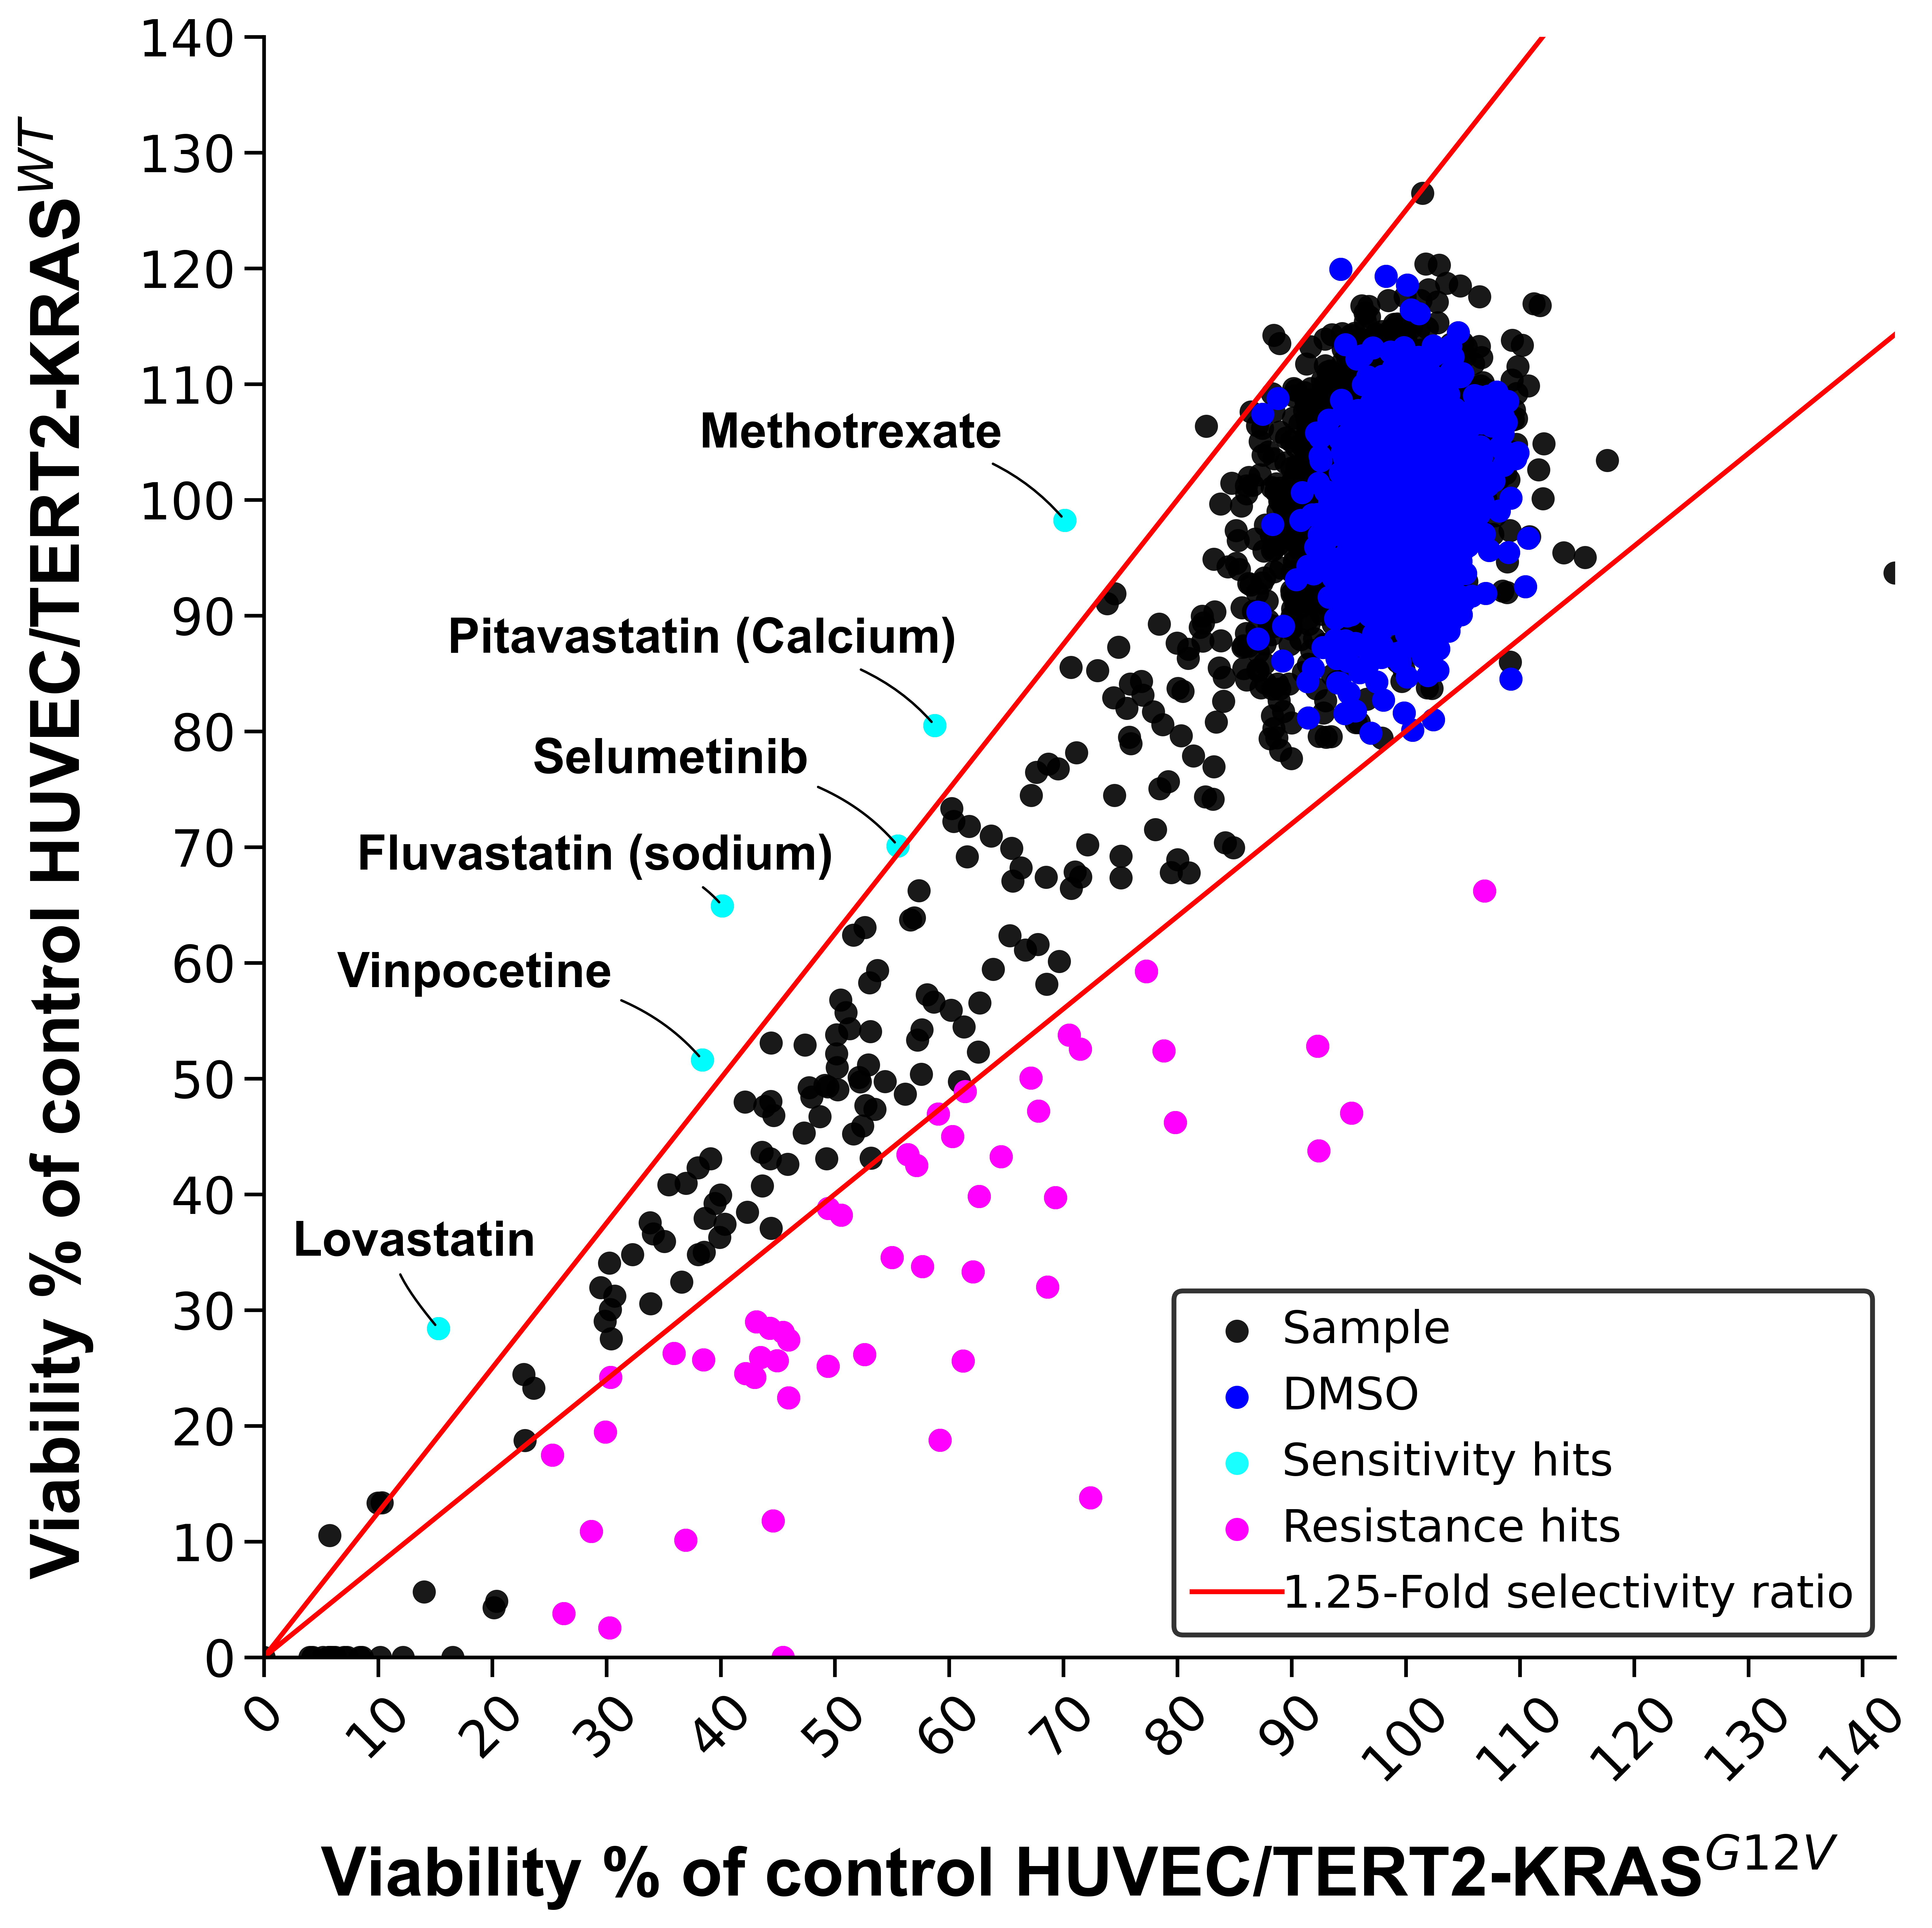

In [22]:
import matplotlib.pyplot as plt
import numpy as np

x1 = dmso['Viability % of control HUVEC/TERT2-KRAS$^{G12V}$']
y1 = dmso['Viability % of control HUVEC/TERT2-KRAS$^{WT}$']
x = allexport['Viability % of control HUVEC/TERT2-KRAS$^{G12V}$']
y = allexport['Viability % of control HUVEC/TERT2-KRAS$^{WT}$']
xs = sensitivity4['Viability % of control HUVEC/TERT2-KRAS$^{G12V}$']
ys = sensitivity4['Viability % of control HUVEC/TERT2-KRAS$^{WT}$']
sname = sensitivity4.index
xs1 = sensitivity4['Viability % of control HUVEC/TERT2-KRAS$^{G12V}$']
ys1 = sensitivity4['Viability % of control HUVEC/TERT2-KRAS$^{WT}$']
xr = resistance4['Viability % of control HUVEC/TERT2-KRAS$^{G12V}$']
yr = resistance4['Viability % of control HUVEC/TERT2-KRAS$^{WT}$']

hfont = {'fontname': 'arial', 'fontweight': 'bold'}  # Set bold font for axis labels

plt.figure(figsize=(12, 12), dpi=600)
ax = plt.gca()
ax.set_ylim(ax.get_ylim()[::-1])

# Make axes thicker
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Make ticks thicker
ax.tick_params(axis='both', width=1.5, length=8)

# Set axis labels and make them bold
plt.xlabel('Viability % of control HUVEC/TERT2-KRAS$^{G12V}$', fontsize=28, labelpad=18, **hfont)
plt.ylabel('Viability % of control HUVEC/TERT2-KRAS$^{WT}$', fontsize=28, labelpad=18, **hfont)
plt.xticks(np.arange(0, 150, step=10), fontsize=21, fontweight='normal', rotation=45)
plt.yticks(np.arange(0, 150, step=10), fontsize=21, fontweight='normal')
plt.gca().invert_yaxis()

# Set x-axis to start from 0
plt.xlim(0, max(x))  # Set x-axis to start from 0 and go up to the max x value

# Plot the data points
plt.scatter(x, y, s=360, marker='.', color='k', label='Sample', linewidth=0, alpha=0.9)
plt.scatter(x1, y1, s=360, marker='.', color='blue', label='DMSO', linewidth=0, alpha=1)
plt.scatter(xs, ys, s=360, marker='.', color='cyan', label='Sensitivity hits', linewidth=0, alpha=0.9)
plt.scatter(xs1, ys1, s=360, marker='.', color='cyan', linewidth=0, alpha=0.9)
plt.scatter(xr, yr, s=360, marker='.', color='magenta', label='Resistance hits', linewidth=0, alpha=1)

# Plot the line y = 1.25 * x (but do not include it in the legend)
x_line = np.linspace(min(x), max(x), 100)  # Generate x values for the line
y_line = 1.25 * x_line  # Calculate the corresponding y values

x_line2 = np.linspace(min(x), max(x), 100)  # Generate x values for the line
y_line2 = (1/1.25) * x_line2  # Calculate the corresponding y values

# Plot the lines without adding to the legend
plt.plot(x_line, y_line, color='red', linewidth=2, label='1.25-Fold selectivity ratio')
plt.plot(x_line2, y_line2, color='red', linewidth=2)

# Create the legend without the red lines
legend = plt.legend(loc="lower right", prop={'size': 18.5}, handletextpad=0)
legend.get_frame().set_linewidth(2)  # Set legend border linewidth
legend.get_frame().set_edgecolor('black')  # Set legend border color

# Annotate points with bold labels
for i, txt in enumerate(sname):
    # Apply the same dynamic offset along the y-axis for other points (moving in the opposite direction)
    offset_y = 50
    offset_x = -100
    
    # Apply a special offset for "Lovastatin"
    if txt == 'Lovastatin':
        offset_x = -60  # Increase the offset in x-direction
        offset_y = 30   # Decrease the offset in y-direction

        # Apply a special offset for "Pitavastatin"
    if txt == 'Pitavastatin (Calcium)':
        offset_x = -200 # Increase the offset in x-direction
        offset_y = 30   # Decrease the offset in y-direction

        # Apply a special offset for "Fluvastatin"
    if txt == 'Fluvastatin (sodium)':
        offset_x = -150 # Increase the offset in x-direction
        offset_y = 15   # Decrease the offset in y-direction

    # Apply a special offset for "Vinpocetine"
    if txt == 'Vinpocetine':
        offset_x = -150 # Increase the offset in x-direction
        offset_y = 30   # Decrease the offset in y-direction

     # Apply a special offset for "Methotrexate"
    if txt == 'Methotrexate':
        offset_x = -150 # Increase the offset in x-direction
        offset_y = 30   # Decrease the offset in y-direction

    # Apply a special offset for "Methotrexate"
    if txt == 'Selumetinib':
        offset_x = -150 # Increase the offset in x-direction
        offset_y = 30   # Decrease the offset in y-direction


    # Annotate each point with the calculated offset using .iloc[i]
    ax.annotate(txt, (xs.iloc[i], ys.iloc[i]), fontsize=20, xytext=(offset_x, offset_y), **hfont, 
                textcoords='offset points', arrowprops=dict(arrowstyle="-", connectionstyle="angle3,angleA=0,angleB=-50"))

# Define file paths
pdf_path = r'path_to_output_folder\Figure2A_2uM_Output_plot.pdf'
tiff_path = r'path_to_output_folder\Figure2A_2uM_Output_plot.TIFF'

# Save as PDF and TIFF
plt.savefig(pdf_path, bbox_inches='tight', format='pdf')  # Save as PDF
plt.savefig(tiff_path, bbox_inches='tight', format='TIFF')  # Save as TIFF
